In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

## Exercise: get monthly job postings count for top data jobs in the United States

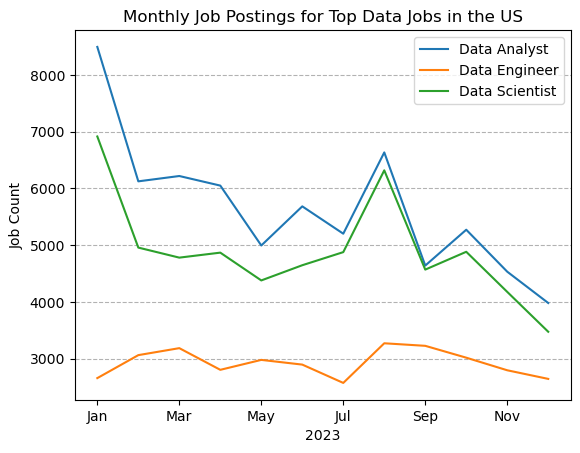

In [60]:
import calendar

# retrive the top 3 most common data jobs
top_job_postings = df["job_title_short"].value_counts().head(3).index

# filter dataframe to have only United States job postings
job_postings_us = df.loc[
    (df["job_country"] == "United States") & (df["job_title_short"].isin(top_job_postings)),
    :
]

# extract the months from the job_posted_date column
job_postings_us["job_posted_month"] = job_postings_us["job_posted_date"].dt.month

# create aggregation
aggregation = job_postings_us.pivot_table(
    index="job_posted_month", 
    columns="job_title_short",
    aggfunc="size"
)

aggregation.index = [calendar.month_abbr[x] for x in aggregation.index]

aggregation.plot()
plt.title("Monthly Job Postings for Top Data Jobs in the US")
plt.ylabel("Job Count")
plt.xlabel("2023")
plt.grid(True, color="gray", axis="y", linestyle="--", alpha=0.6)
plt.legend(title=None)
plt.show()

In [46]:
job_postings_us.info()

<class 'pandas.DataFrame'>
Index: 161726 entries, 3 to 785705
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        161726 non-null  str           
 1   job_title              161726 non-null  str           
 2   job_location           161127 non-null  str           
 3   job_via                161719 non-null  str           
 4   job_schedule_type      160657 non-null  str           
 5   job_work_from_home     161726 non-null  bool          
 6   search_location        161726 non-null  str           
 7   job_posted_date        161726 non-null  datetime64[us]
 8   job_no_degree_mention  161726 non-null  bool          
 9   job_health_insurance   161726 non-null  bool          
 10  job_country            161726 non-null  str           
 11  salary_rate            19956 non-null   str           
 12  salary_year_avg        11818 non-null   float64       
 13  